COMPARE RSI VS PRICE ACTION TRADING STRATEGIES IN PYTHON

Step 1: Import Libraries

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Step 2: Download historical stock data

In [16]:
api_key = 'your_api_key'
symbol = 'TSLA'

url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&apikey={api_key}'
response = requests.get(url)
data = response.json()

# Analyse and clean the data

df = pd.DataFrame(data['Time Series (Daily)']).T
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df = df.astype(float)
df = df[['4. close']].rename(columns={'4. close': 'Close'})

Step 3: RSI Strategy


In [17]:
def calculate_rsi(series, period=14):
  delta = series.diff()
  gain =  delta.clip(lower=0).rolling(window=period).mean()
  loss = -delta.clip(upper=0).rolling(window=period).mean()
  rs = gain / loss
  return 100 - (100 / (1 + rs))

df['RSI'] = calculate_rsi(df['Close'])
df['RSI_Signal'] = 0
df.loc[df['RSI'] < 30, 'RSI_Signal'] = 1
df.loc[df['RSI'] > 70, 'RSI_Signal'] = -1
df['RSI_Position'] = df['RSI_Signal'].shift()

Step 4:  Price action Breakout Strategy

In [18]:
df['SD_High'] = df['Close'].rolling(window=5).max().shift(1)
df['SD_Low'] = df['Close'].rolling(window=5).min().shift(1)

df['PA_Signal'] = 0
df.loc[df['Close'] > df['SD_High'], 'PA_Signal'] = 1
df.loc[df['Close'] < df['SD_Low'], 'PA_Signal'] = -1

df['PA_Position'] = df['PA_Signal'].shift()

Backtest & Plot

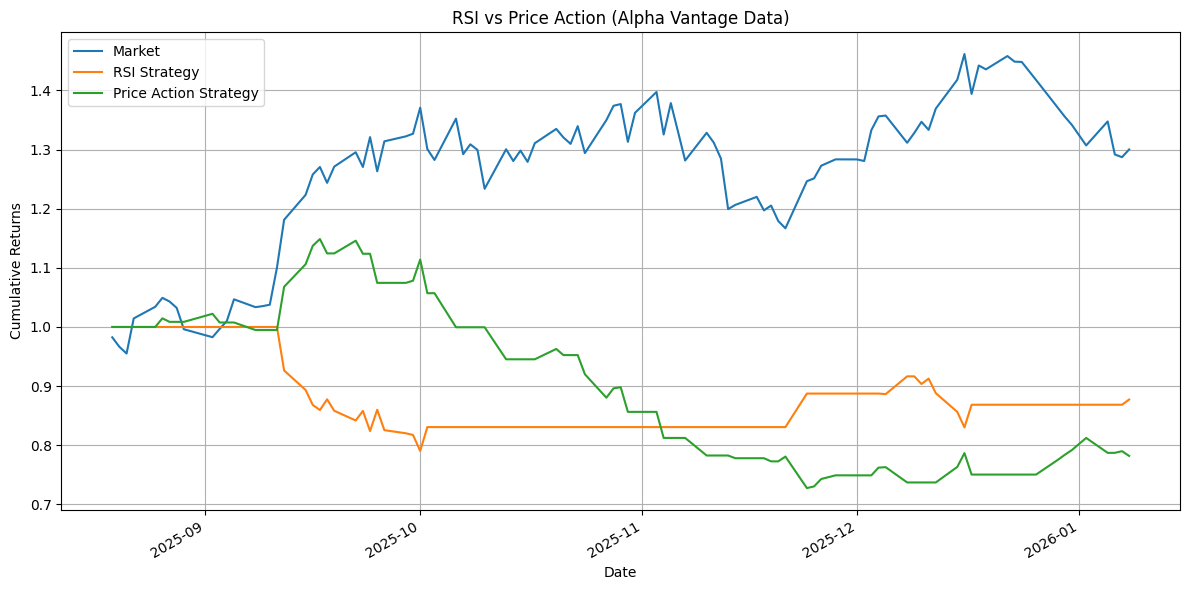

In [20]:
df['Market Return'] = df['Close'].pct_change()
df['RSI Strategy'] = df['Market Return'] * df['RSI_Position']
df['PA Strategy'] = df['Market Return'] * df['PA_Position']

(1 + df[['Market Return', 'RSI Strategy', 'PA Strategy']]).cumprod().plot(figsize=(12,6))
plt.title('RSI vs Price Action (Alpha Vantage Data)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend(['Market', 'RSI Strategy', 'Price Action Strategy'])
plt.grid(True)
plt.tight_layout()
plt.show()